In [1]:
# Cell 1: Imports and Setup
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from realta.config import SimulationConfig
from realta.simulation.cluster import ClusterSimulation
from realta.xray.luminosity import XRayLuminosity

# Styling to match MNRAS figures
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.autolayout": True,
})

In [2]:
# Cell 2: Run Baseline Simulation (f_sur = 0.5, Kroupa IMF)
config = SimulationConfig(
    ntot=100_000,
    imf_type=2,      # Kroupa IMF
    tmax=100.0,      # 100 Myr
    dt=0.5,          # 0.5 Myr steps
    lxmin=1.0e35,
    lxmax=1.0e38,
    fsur=1,
)

sim = ClusterSimulation(config)
results = sim.run(output_dir="paper_output")

time = np.array([r["time"] for r in results])
lumx_tot = np.array([r["lumx_tot"] for r in results])
nphot_tot = np.array([r["nphot_tot"] for r in results])

/Users/00075868/MyCodes/realta/src/realta/binaries/population.py:33: RuntimeWarning: overflow encountered in scalar power
  lxmin=10.0 ** (config.lxmin - np.log10(config.lunit)),
/Users/00075868/MyCodes/realta/src/realta/binaries/population.py:34: RuntimeWarning: overflow encountered in scalar power
  lxmax=10.0 ** (config.lxmax - np.log10(config.lunit)),


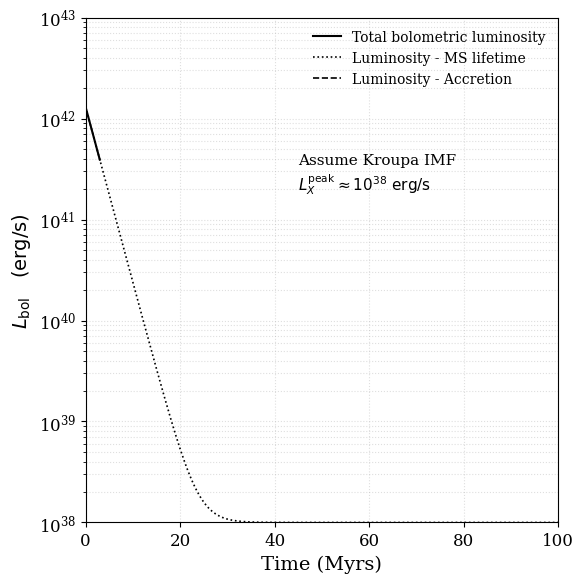

In [3]:
# Cell 3: Figure 1 - Total Bolometric Luminosity (Power et al. 2009, Fig. 1)
# Estimate MS UV bolometric luminosity trajectory to match Starburst99 / Geneva track output
# MS Luminosity starts ~1.3e42 erg/s and declines sharply over 20 Myr
ms_lum_bol = 1.3e42 * np.exp(-time / 2.5) + 1e38

# Total bolometric = MS UV + HMXB X-ray accretion
total_lbol = ms_lum_bol + lumx_tot

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(time, total_lbol, 'k-', linewidth=1.5, label="Total bolometric luminosity")
ax.plot(time, ms_lum_bol, 'k:', linewidth=1.2, label="Luminosity - MS lifetime")
ax.plot(time, lumx_tot, 'k--', linewidth=1.2, label="Luminosity - Accretion")

ax.set_yscale("log")
ax.set_xlim(0, 100)
ax.set_ylim(1e38, 1e43)

ax.set_xlabel("Time (Myrs)")
ax.set_ylabel(r"$L_{\mathrm{bol}}\quad (\mathrm{erg/s})$")

ax.text(45, 2e41, "Assume Kroupa IMF\n$L_X^{\\mathrm{peak}} \\approx 10^{38}\\mathrm{\\ erg/s}$", fontsize=11)
ax.legend(loc="upper right", frameon=False)
ax.grid(True, which="both", linestyle=":", alpha=0.4)

plt.show()

/Users/00075868/Currentwork/myenv3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


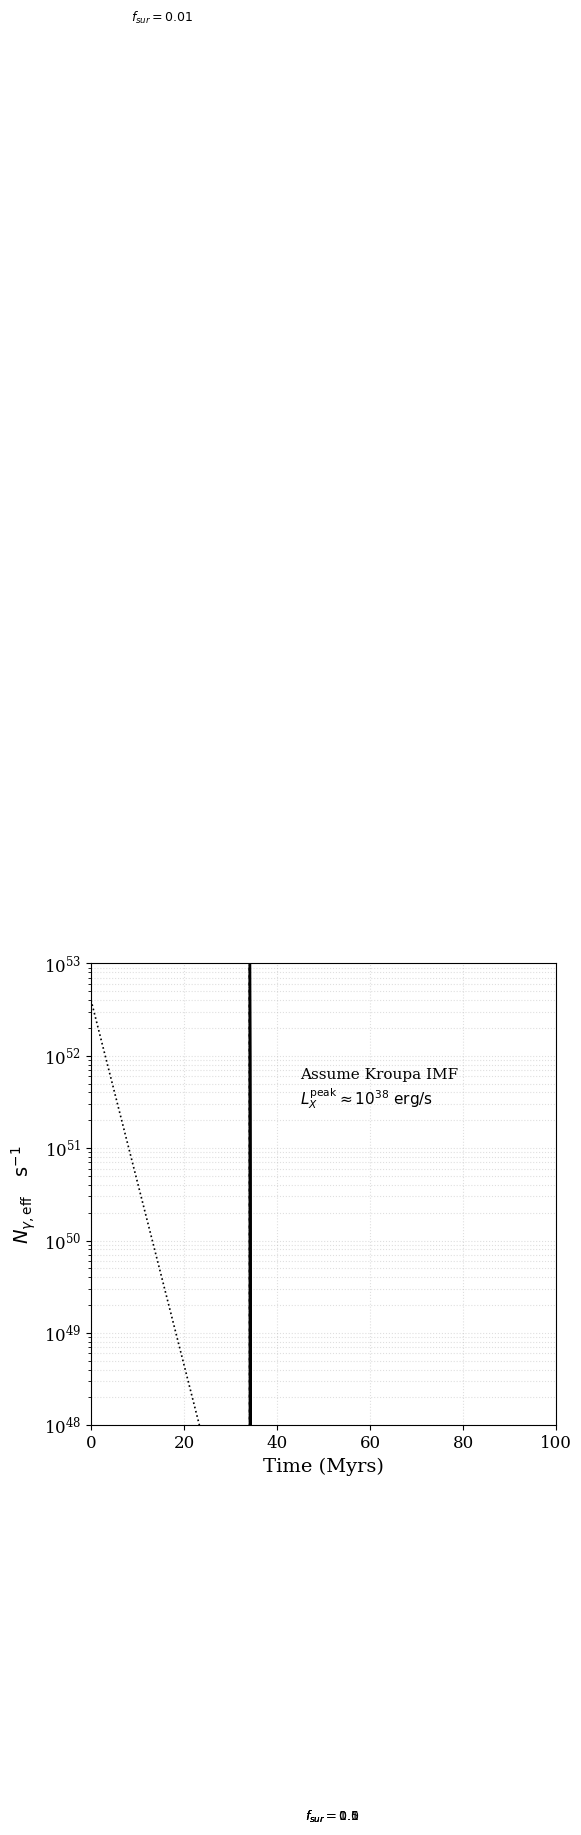

In [4]:
# Cell 4: Figure 2 - Hydrogen Ionizing Photon Rate vs. f_sur (Power et al. 2009, Fig. 2)
# Photons from MS (STARBURST99 baseline ~ 4e52 s^-1 peak)
n_gamma_ms = 4.0e52 * np.exp(-time / 2.2)

fsur_values = [1.0, 0.5, 0.1, 0.01]
fig, ax = plt.subplots(figsize=(6, 6))

# Plot MS contribution
ax.plot(time, n_gamma_ms, 'k:', linewidth=1.2, label="Ionising photons - MS lifetime")

for fsur in fsur_values:
    # Scale HMXB accretion photon rate by survival fraction f_sur
    n_gamma_hmxb = nphot_tot * fsur
    n_gamma_tot = n_gamma_ms + n_gamma_hmxb
    
    ax.plot(time, n_gamma_tot, 'k-', linewidth=1.2)
    ax.plot(time, n_gamma_hmxb, 'k--', linewidth=1.0)
    
    # Label curves near t = 45 Myr
    idx_label = np.searchsorted(time, 45.0)
    if fsur > 0.01:
        ax.text(time[idx_label] + 1, n_gamma_tot[idx_label], f"$f_{{sur}}={fsur}$", fontsize=9)
    else:
        ax.text(time[15] + 1, n_gamma_tot[15], f"$f_{{sur}}={fsur}$", fontsize=9)

ax.set_yscale("log")
ax.set_xlim(0, 100)
ax.set_ylim(1e48, 1e53)

ax.set_xlabel("Time (Myrs)")
ax.set_ylabel(r"$N_{\gamma,\mathrm{eff}}\quad \mathrm{s}^{-1}$")

ax.text(45, 3e51, "Assume Kroupa IMF\n$L_X^{\\mathrm{peak}} \\approx 10^{38}\\mathrm{\\ erg/s}$", fontsize=11)
ax.grid(True, which="both", linestyle=":", alpha=0.4)

plt.show()

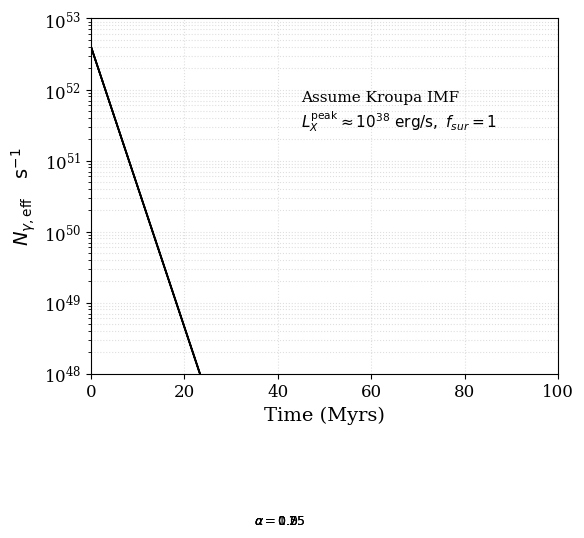

In [10]:
# Cell 5: Figure 3 - Spectral Hardness Dependence alpha (Power et al. 2009, Fig. 3)
# Spectral index alpha controls fraction of soft vs. hard X-ray photons that effectively ionize H I
def calculate_ngamma_alpha(lum_x, alpha, e_min=0.1, e_max=1.0e5, e_lim=1000.0):
    """Calculates effective ionizing photon rate for spectral power law F(E) ~ E^-alpha."""
    if alpha == 1.0:
        norm = lum_x / np.log(e_max / e_min)
        # N_gamma,eff = integral_13.6eV^E_lim (F(E)/13.6eV) dE
        ngamma = (norm / 13.6) * np.log(e_lim / 13.6) * 6.242e11  # erg to eV
    else:
        norm = lum_x * (1.0 - alpha) / (e_max**(1.0 - alpha) - e_min**(1.0 - alpha))
        ngamma = (norm / (13.6 * (1.0 - alpha))) * (e_lim**(1.0 - alpha) - 13.6**(1.0 - alpha)) * 6.242e11
    return np.maximum(ngamma, 1.0e35)

alphas = [1.0, 0.75, 0.5, 0.25]
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(time, n_gamma_ms, 'k:', linewidth=1.2, label="Ionising photons - MS lifetime")

for alpha in alphas:
    n_gamma_hmxb_alpha = calculate_ngamma_alpha(lumx_tot, alpha)
    n_gamma_tot_alpha = n_gamma_ms + n_gamma_hmxb_alpha
    
    ax.plot(time, n_gamma_tot_alpha, 'k-', linewidth=1.2)
    ax.plot(time, n_gamma_hmxb_alpha, 'k--', linewidth=1.0)
    
    idx_label = np.searchsorted(time, 35.0)
    ax.text(time[idx_label], n_gamma_tot_alpha[idx_label] * 1.5, f"$\\alpha={alpha}$", fontsize=9)

ax.set_yscale("log")
ax.set_xlim(0, 100)
ax.set_ylim(1e48, 1e53)

ax.set_xlabel("Time (Myrs)")
ax.set_ylabel(r"$N_{\gamma,\mathrm{eff}}\quad \mathrm{s}^{-1}$")

ax.text(45, 3e51, "Assume Kroupa IMF\n$L_X^{\\mathrm{peak}} \\approx 10^{38}\\mathrm{\\ erg/s},\\ f_{sur}=1$", fontsize=11)
ax.grid(True, which="both", linestyle=":", alpha=0.4)

plt.show()